# Simple Logistic Regression

## 1. Nạp thư viện

In [ ]:
# Thư viện để phân tích dữ liệu, thao tác với dữ liệu dạng bảng, chuỗi thời gian.
import pandas as pd
# Thư viện để tính toán khoa học, xử lý mảng và ma trận.
import numpy as np
# thư viện vẽ biểu đồ
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Nạp dữ liệu

In [ ]:
dataset = pd.read_csv('/content/Social_Network_Ads.csv')
dataset.head(10)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


In [ ]:
# xem info coi có dữ liệu nào thiếu hay không
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [ ]:

dataset.describe(include='all')

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


## Xem ma trận tương quan


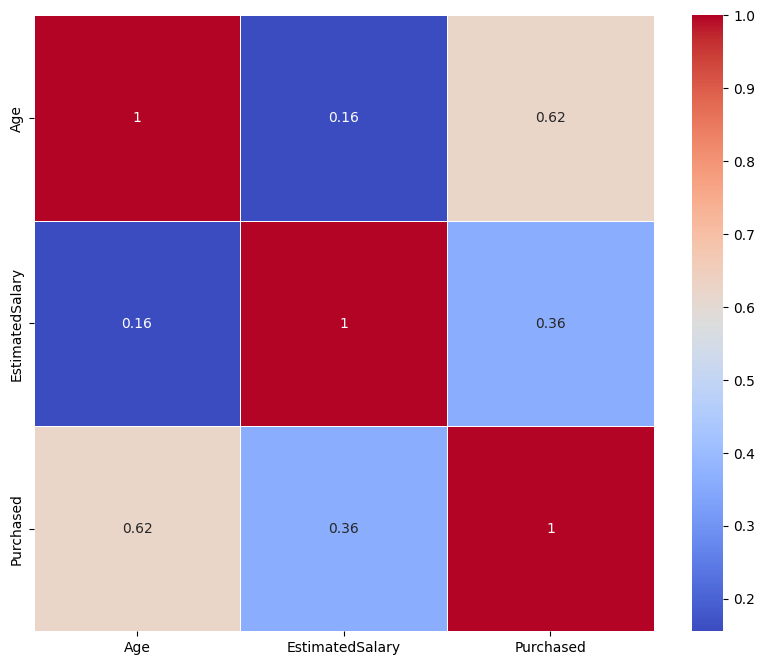

In [ ]:
corr_matrix = dataset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

## Feature Scaling

## Chia tập huấn luyện và tập kiểm thử

In [ ]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [ ]:
print(X)

     Age  EstimatedSalary
0     19            19000
1     35            20000
2     26            43000
3     27            57000
4     19            76000
..   ...              ...
395   46            41000
396   51            23000
397   50            20000
398   36            33000
399   49            36000

[400 rows x 2 columns]


## Huấn luyện mô hình

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2,random_state=0)


In [13]:
#chuẩn hóa
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [15]:
y_pred = model.predict(X_test)

## Đánh giá mô hình

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
print('Accurancy:', accuracy_score(y_test,y_pred))
print('Ma trận nhầm lẫn :', confusion_matrix(y_test,y_pred))
print('Báo cáo :', classification_report(y_test,y_pred))

Accurancy: 0.925
Ma trận nhầm lẫn : [[57  1]
 [ 5 17]]
Báo cáo :               precision    recall  f1-score   support

           0       0.92      0.98      0.95        58
           1       0.94      0.77      0.85        22

    accuracy                           0.93        80
   macro avg       0.93      0.88      0.90        80
weighted avg       0.93      0.93      0.92        80

